# 02. Exploratory Data Analysis (EDA) & Visualizations

## Overview
This notebook performs **Exploratory Data Analysis (EDA)** and generates high-impact visual plots for the Customer Persona project.
We analyze univariate distributions, bivariate relationships, density contours, and outlier spreads for `annual_income_k` and `spending_score`.

All key visualization artifacts are exported to `../reports/figures/` for Shalini's final handoff package.


## 1. Imports & Dataset Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

# Ensure figures directory exists
figures_dir = "../reports/figures"
os.makedirs(figures_dir, exist_ok=True)

# Load processed customer dataset
data_path = "../data/processed/Customer_Data.csv"
df = pd.read_csv(data_path)
print("Loaded dataset with shape:", df.shape)
df.head()

Loaded dataset with shape: (600, 2)


,annual_income_k,spending_score
0,34.0,82.9
1,28.9,84.5
2,35.2,88.7
3,42.2,88.4
4,28.1,69.0


## 2. Distribution & Statistical Summary Analysis

In [2]:
# Detailed statistical summary
stats_df = df.describe().T
stats_df['median'] = df.median()
stats_df['skewness'] = df.skew()
stats_df['kurtosis'] = df.kurtosis()
stats_df['IQR'] = df.quantile(0.75) - df.quantile(0.25)
stats_df

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,IQR
annual_income_k,600.0,68.380833,28.833117,15.0,34.075,80.5,90.700,120.8,80.5,-0.531630,-1.307049,56.625
spending_score,600.0,63.887167,28.681534,3.4,30.575,77.1,86.125,100.0,77.1,-0.620339,-1.278139,55.550


## 3. Univariate Feature Distributions (Histograms & KDE)

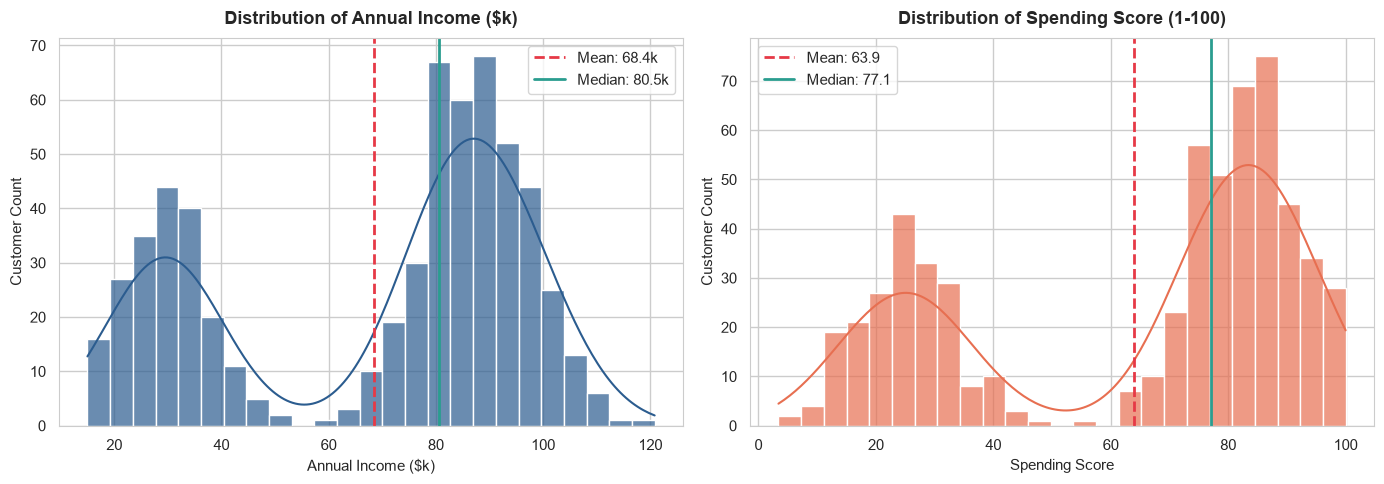

Saved distribution plot to ../reports/figures\feature_distributions.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Annual Income Distribution
sns.histplot(df['annual_income_k'], kde=True, ax=axes[0], color="#2b5c8f", bins=25, alpha=0.7)
axes[0].set_title("Distribution of Annual Income ($k)", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("Annual Income ($k)", fontsize=11)
axes[0].set_ylabel("Customer Count", fontsize=11)
axes[0].axvline(df['annual_income_k'].mean(), color='#e63946', linestyle='--', linewidth=2, label=f"Mean: {df['annual_income_k'].mean():.1f}k")
axes[0].axvline(df['annual_income_k'].median(), color='#2a9d8f', linestyle='-', linewidth=2, label=f"Median: {df['annual_income_k'].median():.1f}k")
axes[0].legend()

# Plot 2: Spending Score Distribution
sns.histplot(df['spending_score'], kde=True, ax=axes[1], color="#e76f51", bins=25, alpha=0.7)
axes[1].set_title("Distribution of Spending Score (1-100)", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("Spending Score", fontsize=11)
axes[1].set_ylabel("Customer Count", fontsize=11)
axes[1].axvline(df['spending_score'].mean(), color='#e63946', linestyle='--', linewidth=2, label=f"Mean: {df['spending_score'].mean():.1f}")
axes[1].axvline(df['spending_score'].median(), color='#2a9d8f', linestyle='-', linewidth=2, label=f"Median: {df['spending_score'].median():.1f}")
axes[1].legend()

plt.tight_layout()
fig_path = os.path.join(figures_dir, "feature_distributions.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved distribution plot to {fig_path}")

## 4. Outlier & Spread Assessment (Box & Violin Plots)

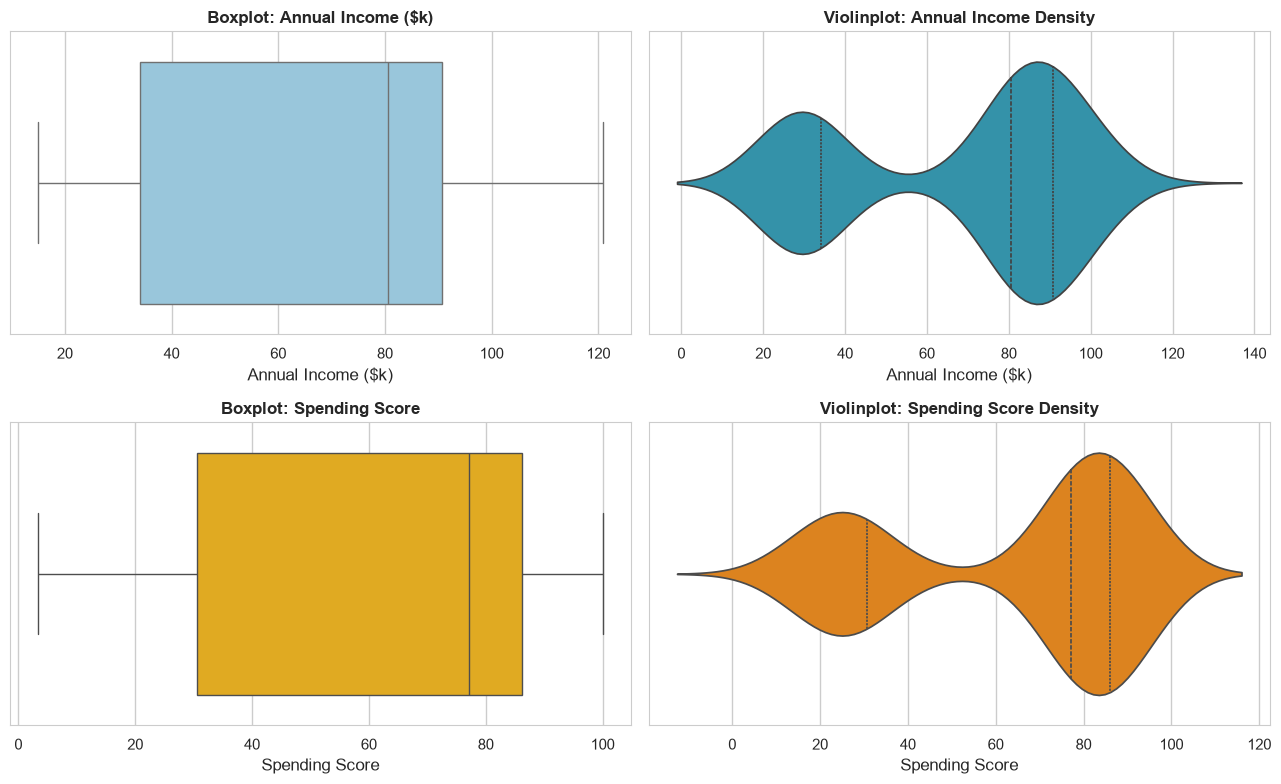

Saved box & violin plot to ../reports/figures\boxplot_outliers.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Boxplot Annual Income
sns.boxplot(x=df['annual_income_k'], ax=axes[0,0], color="#8ecae6", flierprops={"markerfacecolor": "red", "markersize": 8})
axes[0,0].set_title("Boxplot: Annual Income ($k)", fontweight='bold')
axes[0,0].set_xlabel("Annual Income ($k)")

# Violinplot Annual Income
sns.violinplot(x=df['annual_income_k'], ax=axes[0,1], color="#219ebc", inner="quartile")
axes[0,1].set_title("Violinplot: Annual Income Density", fontweight='bold')
axes[0,1].set_xlabel("Annual Income ($k)")

# Boxplot Spending Score
sns.boxplot(x=df['spending_score'], ax=axes[1,0], color="#ffb703", flierprops={"markerfacecolor": "red", "markersize": 8})
axes[1,0].set_title("Boxplot: Spending Score", fontweight='bold')
axes[1,0].set_xlabel("Spending Score")

# Violinplot Spending Score
sns.violinplot(x=df['spending_score'], ax=axes[1,1], color="#fb8500", inner="quartile")
axes[1,1].set_title("Violinplot: Spending Score Density", fontweight='bold')
axes[1,1].set_xlabel("Spending Score")

plt.tight_layout()
fig_path = os.path.join(figures_dir, "boxplot_outliers.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved box & violin plot to {fig_path}")

## 5. Customer Segmentation Scatter Analysis (`annual_income_k` vs `spending_score`)

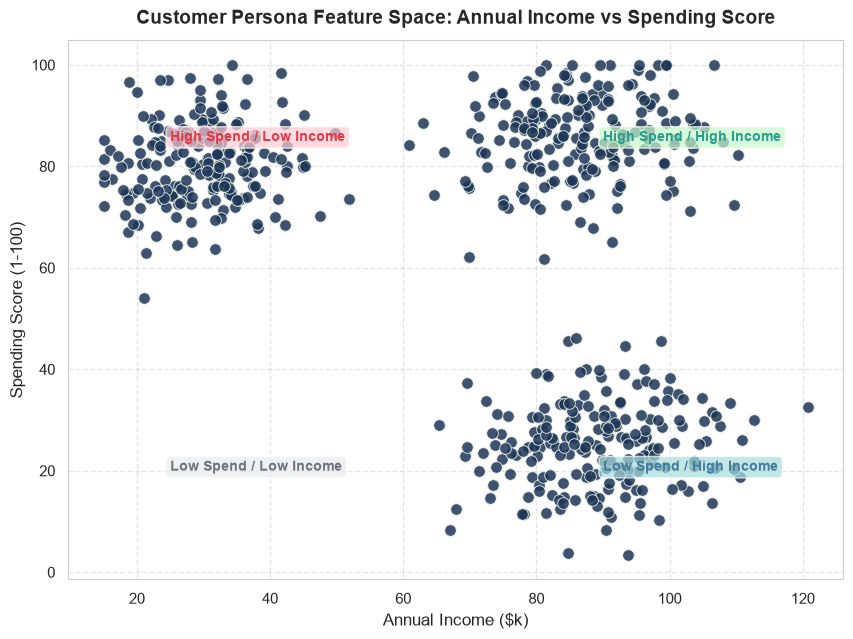

Saved scatter plot to ../reports/figures\income_vs_spending_scatter.png


In [5]:
plt.figure(figsize=(10, 7))

# Scatter plot showing customer distribution across features
sns.scatterplot(
    data=df, 
    x='annual_income_k', 
    y='spending_score', 
    alpha=0.85, 
    s=70, 
    color='#1d3557',
    edgecolor='#f1faee'
)

plt.title("Customer Persona Feature Space: Annual Income vs Spending Score", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Annual Income ($k)", fontsize=12)
plt.ylabel("Spending Score (1-100)", fontsize=12)

# Annotate expected cluster regions for Customer Personas
plt.text(25, 85, "High Spend / Low Income", fontsize=10, fontweight='bold', color='#e63946', bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffccd5', alpha=0.7))
plt.text(90, 85, "High Spend / High Income", fontsize=10, fontweight='bold', color='#2a9d8f', bbox=dict(boxstyle='round,pad=0.3', facecolor='#c7f9cc', alpha=0.7))
plt.text(90, 20, "Low Spend / High Income", fontsize=10, fontweight='bold', color='#457b9d', bbox=dict(boxstyle='round,pad=0.3', facecolor='#a8dede', alpha=0.7))
plt.text(25, 20, "Low Spend / Low Income", fontsize=10, fontweight='bold', color='#6c757d', bbox=dict(boxstyle='round,pad=0.3', facecolor='#e9ecef', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.5)
fig_path = os.path.join(figures_dir, "income_vs_spending_scatter.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved scatter plot to {fig_path}")

## 6. Bivariate KDE Density Contours & Joint Density Plot

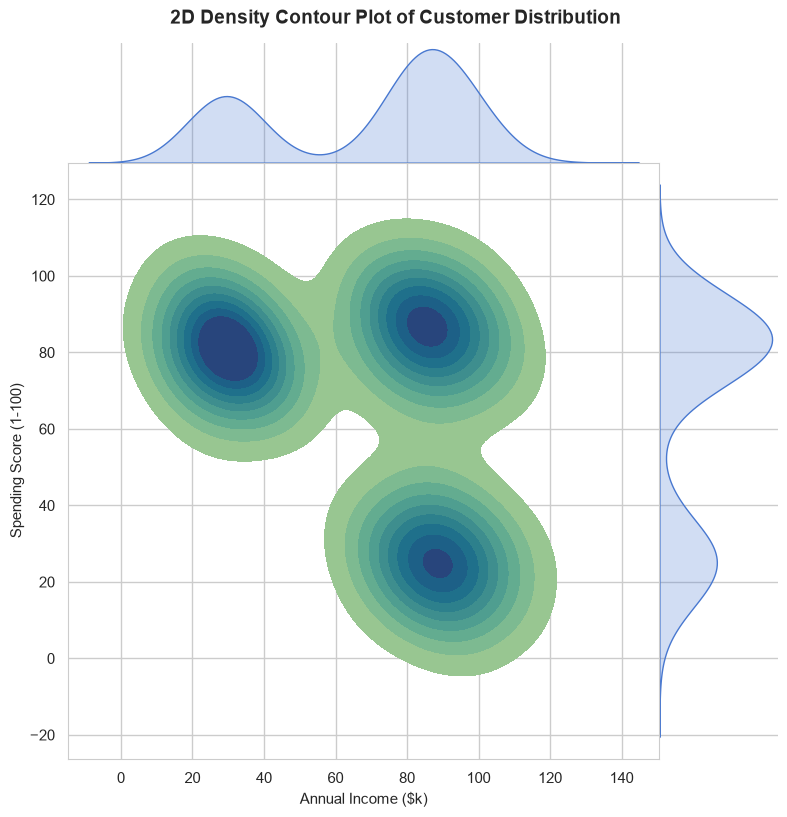

Saved KDE contour plot to ../reports/figures\kde_density_contour.png


In [6]:
g = sns.jointplot(
    data=df,
    x='annual_income_k',
    y='spending_score',
    kind='kde',
    fill=True,
    cmap='crest',
    height=8,
    space=0
)
g.fig.suptitle("2D Density Contour Plot of Customer Distribution", y=1.02, fontsize=14, fontweight='bold')
g.set_axis_labels("Annual Income ($k)", "Spending Score (1-100)", fontsize=11)

fig_path = os.path.join(figures_dir, "kde_density_contour.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved KDE contour plot to {fig_path}")

## 7. Key Visual Findings & EDA Summary

1. **Feature Range & Distribution**:
   - `annual_income_k` spans from ~$15k to ~$120k+, showing distinct density peaks representing different income brackets.
   - `spending_score` spans from ~3 to ~100 with uniform to multi-modal behavior across customer segments.

2. **Cluster Persona Readiness**:
   - The scatter plot clearly reveals natural cluster groupings (e.g. High Income/High Spend, High Income/Low Spend, Low Income/High Spend, Moderate Income/Moderate Spend).
   - Distance-based clustering models (K-Means / DBSCAN / Agglomerative) will easily isolate distinct customer personas.

3. **Outliers**:
   - No severe anomalies or extreme corrupt data points detected; distribution is well-behaved and suitable for scaling.
